# Fase 1: Carregamento e Análise Exploratória de Imagens (EDA)

Importações das bibliotecas

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml


### Carregamento do dataset e dimensionamento

In [ ]:
print("Baixando o dataset MNIST...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X, y = mnist.data, mnist.target.astype(np.uint8)
print("Download concluído!")

Baixando o dataset MNIST...
Download concluído!


In [ ]:
print(f"Formato de X (amostras, pixels por imagem): {X.shape}")
print(f"Formato de y (rótulos): {y.shape}")
print(f"Tipo de dado dos pixels: {X.dtype}")
print(f"Valor mínimo de pixel: {X.min()} | Valor máximo de pixel: {X.max()}")

Formato de X (amostras, pixels por imagem): (70000, 784)
Formato de y (rótulos): (70000,)
Tipo de dado dos pixels: int64
Valor mínimo de pixel: 0 | Valor máximo de pixel: 255


### Distribuição das classes (Balanceamento)

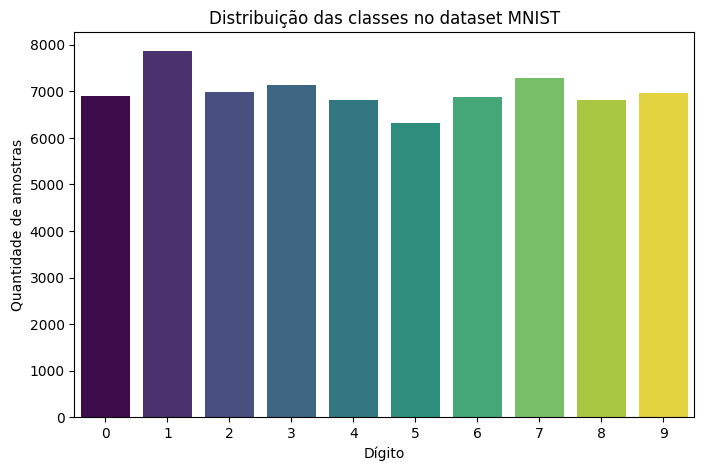

0    6903
1    7877
2    6990
3    7141
4    6824
5    6313
6    6876
7    7293
8    6825
9    6958
dtype: int64


In [ ]:
classes, contagens = np.unique(y, return_counts=True)

plt.figure(figsize=(8, 5))
sns.barplot(x=classes, y=contagens, hue=classes, palette='viridis', legend=False)
plt.title("Distribuição das classes no dataset MNIST")
plt.xlabel("Dígito")
plt.ylabel("Quantidade de amostras")
plt.show()

print(pd.Series(contagens, index=classes))

### Grade visual 2×5 (com um exemplo de CADA dígito)

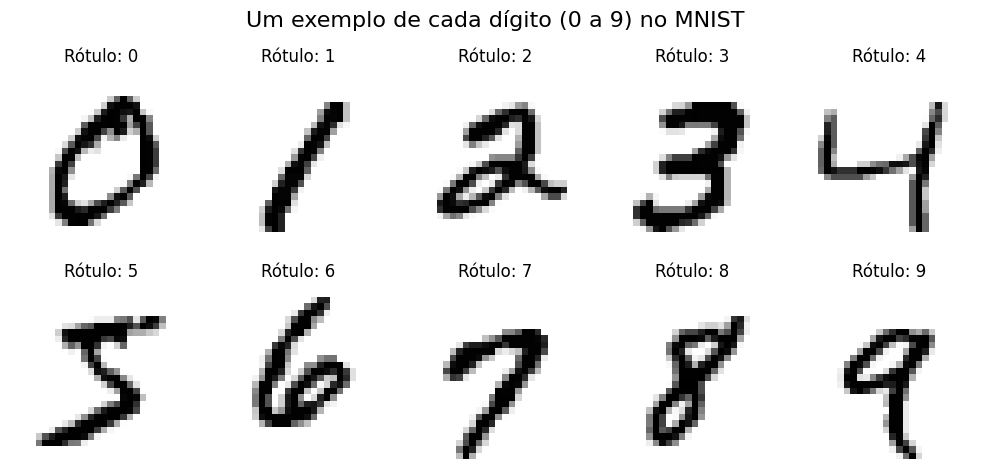

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for digito, ax in enumerate(axes.flat):
    # Pega o índice da PRIMEIRA imagem que representa esse dígito
    indice = np.where(y == digito)[0][0]
    ax.imshow(X[indice].reshape(28, 28), cmap='binary')
    ax.set_title(f"Rótulo: {y[indice]}")
    ax.axis('off')

plt.suptitle("Um exemplo de cada dígito (0 a 9) no MNIST", fontsize=16)
plt.tight_layout()
plt.show()

# Interpretação da estrutura dos dados

* Imagine o dataset MNIST (70.000 imagens de dígitos manuscritos de 0 a 9 em
escala de cinza, 28x28 pixels) como uma pilha de cartas de baralho desenhadas
à mão por milhares de pessoas diferentes. Cada carta do MNIST é um pequeno
tabuleiro quadriculado de 28 linhas por 28 colunas (totalizando 784
quadradinhos).

* Cada quadradinho dessa carta não é só preto ou branco, mas guarda um número
que indica a intensidade do tom: 0 é preto, um número intermediário como 130
é cinza, e 255 é branco.

* Quando olhamos para a carta na mão, vemos o desenho em duas dimensões (altura
e largura). O problema é que algoritmos tabulares clássicos (como KNN,
Regressão Logística ou Random Forest) não sabem "segurar" uma carta quadrada.
Eles só sabem ler uma planilha do Excel com linhas e colunas normais.

* Para isso, precisamos "cortar" a carta em 28 tiras horizontais (cada tira tem
1 quadradinho de altura por 28 de largura) e colocar uma tira ao lado da
outra sequencialmente até a 28ª tira. O resultado não é mais uma carta
quadrada: virou uma fita longa e esticada com 784 quadradinhos em fila
indiana, virando assim uma planilha.

* Agora qualquer algoritmo tradicional de Machine Learning consegue treinar
com essa tabela, tratando cada pixel simplesmente como uma característica
numérica comum (como idade, salário ou temperatura).

# Fase 2: Pré-processamento e Divisão dos Dados

Normalização dos pixels

In [ ]:
# Os pixels originais variam de 0 a 255 (inteiros).
# Vamos "reescalar" esses valores para o intervalo [0.0, 1.0], dividindo tudo por 255.0.
# Isso deixa a escala numérica pequena e uniforme, o que ajuda o treinamento
# da Rede Neural a ser mais rápido e estável (evita gradientes instáveis).
X_normalizado = X / 255.0

print(f"Antes  -> mínimo: {X.min()}, máximo: {X.max()}")
print(f"Depois -> mínimo: {X_normalizado.min()}, máximo: {X_normalizado.max()}")

Antes  -> mínimo: 0, máximo: 255
Depois -> mínimo: 0.0, máximo: 1.0


In [ ]:
from sklearn.model_selection import train_test_split

# O train_test_split só sabe dividir em DUAS partes por vez.
# Como queremos TRÊS conjuntos (treino, validação, teste), fazemos em 2 etapas.

# Etapa 1: separamos primeiro o conjunto de TESTE (vai ficar "trancado na gaveta"
# até a Fase 4 - avaliação final). Usamos 15% dos dados para teste.
X_temp, X_test, y_temp, y_test = train_test_split(
    X_normalizado, y,
    test_size=0.15,
    random_state=42,   # garante que o "sorteio" seja sempre o mesmo, reprodutível
    stratify=y          # mantém a proporção de cada dígito (0-9) igual à original
)

# Etapa 2: do que sobrou (X_temp, 85% dos dados), separamos a VALIDAÇÃO.
# Queremos que a validação também represente ~15% do TOTAL original,
# não 15% do que sobrou. Por isso calculamos a fração corrigida:
proporcao_validacao = 0.15 / 0.85  # ≈ 0.1765

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=proporcao_validacao,
    random_state=42,
    stratify=y_temp
)

In [ ]:
total = len(X_normalizado)

print(f"Treino:    {X_train.shape[0]:>6} amostras  ({X_train.shape[0]/total*100:.1f}%)")
print(f"Validação: {X_val.shape[0]:>6} amostras  ({X_val.shape[0]/total*100:.1f}%)")
print(f"Teste:     {X_test.shape[0]:>6} amostras  ({X_test.shape[0]/total*100:.1f}%)")

Treino:     49000 amostras  (70.0%)
Validação:  10500 amostras  (15.0%)
Teste:      10500 amostras  (15.0%)


In [ ]:
import pandas as pd

for nome, y_conjunto in [('Treino', y_train), ('Validação', y_val), ('Teste', y_test)]:
    distrib = pd.Series(y_conjunto).value_counts(normalize=True).sort_index() * 100
    print(f"\nDistribuição de dígitos em {nome} (%):")
    print(distrib.round(2))


Distribuição de dígitos em Treino (%):
0     9.86
1    11.25
2     9.99
3    10.20
4     9.75
5     9.02
6     9.82
7    10.42
8     9.75
9     9.94
Name: proportion, dtype: float64

Distribuição de dígitos em Validação (%):
0     9.87
1    11.25
2     9.99
3    10.20
4     9.74
5     9.02
6     9.82
7    10.42
8     9.75
9     9.94
Name: proportion, dtype: float64

Distribuição de dígitos em Teste (%):
0     9.86
1    11.26
2     9.98
3    10.20
4     9.75
5     9.02
6     9.82
7    10.42
8     9.75
9     9.94
Name: proportion, dtype: float64


# Por que dividir em Treino, Validação e Teste?

* Imagine um cantor/compositor que pretende lançar uma música. Ele começa compondo, rabiscando em papel a letra da música e colocando os primeiros acordes. Nesse estágio, (**Treino**) ele tem a liberdade para errar e recomeçar.

* Após o treino, ele parte para os ensaios em estúdio (**Validação**), onde tem segurança para poder ajustar o que ainda é necessário, mesmo já estando com a versão quase pronta.

* Quando os ajustes necessários foram feitos e validados, a música foi gravada e está pronta para a rádio (**Teste**), onde o público tem acesso e a atenção e o retorno necessário da gravadora (aceitação do público e crítica). Nesse momento não existe mais a opção de ajustar a música. Ou ela é boa ou não.

* Conectando com o Machine Learning — Se a música fosse lançada antes, apenas para uma parte do público em específico (como para um fã clube do artista). Se a música não fosse boa, a "espiada" desse grupo, faria com que a música fosse alterada antes de ser tocada nas rádios (**Teste**). A mesma coisa aconteceria se o cientista de dados "espiasse" o resultado do teste antes da hora e ajustasse o modelo em cima disso. Isso é o que conhecemos por *data leakage*. Dessa forma o teste não seria confiável pois o modelo aprendeu tudo antes da hora.

# Fase 3: Treinamento e Ajuste de Hiperparâmetros

In [ ]:
import time

# Este dicionário guarda os resultados de TODOS os modelos (KNN, Random Forest, Rede Neural).
# Ele será reaproveitado na Fase 4 para montar a tabela comparativa final.
resultados_modelos = {}

## Modelo 1: K-Nearest Neighbors (KNN)


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Vamos testar combinações de 2 hiperparâmetros:
# - n_neighbors: quantos "vizinhos" o modelo consulta antes de decidir
# - weights: se todos os vizinhos "votam" igual (uniform) ou se os mais
#            próximos têm voto com mais peso (distance)

valores_k = [3, 5, 7]
valores_weights = ['uniform', 'distance']

resultados_busca_knn = []

for k in valores_k:
    for peso in valores_weights:
        knn = KNeighborsClassifier(n_neighbors=k, weights=peso, n_jobs=-1)

        inicio = time.time()
        knn.fit(X_train, y_train)
        tempo_total = time.time() - inicio   # cronômetro para AQUI, só mede o treino

        # Previsão e cálculo de acurácia ficam FORA da medição de tempo
        y_val_pred = knn.predict(X_val)
        acuracia_val = accuracy_score(y_val, y_val_pred)

        resultados_busca_knn.append({
            'n_neighbors': k,
            'weights': peso,
            'acuracia_validacao': acuracia_val,
            'tempo_treino_segundos': tempo_total
        })

        print(f"k={k}, weights='{peso}' -> acurácia val: {acuracia_val:.4f} | tempo de treino: {tempo_total:.3f}s")

k=3, weights='uniform' -> acurácia val: 0.9711 | tempo de treino: 0.048s
k=3, weights='distance' -> acurácia val: 0.9717 | tempo de treino: 0.051s
k=5, weights='uniform' -> acurácia val: 0.9703 | tempo de treino: 0.070s
k=5, weights='distance' -> acurácia val: 0.9719 | tempo de treino: 0.050s
k=7, weights='uniform' -> acurácia val: 0.9695 | tempo de treino: 0.049s
k=7, weights='distance' -> acurácia val: 0.9709 | tempo de treino: 0.065s


In [ ]:
import pandas as pd

df_resultados_knn = pd.DataFrame(resultados_busca_knn)
df_resultados_knn.sort_values('acuracia_validacao', ascending=False)

# Pegando a linha com a maior acurácia de validação
melhor_config = df_resultados_knn.loc[df_resultados_knn['acuracia_validacao'].idxmax()]
melhor_k = int(melhor_config['n_neighbors'])
melhor_peso = melhor_config['weights']

print(f"Melhor configuração encontrada: n_neighbors={melhor_k}, weights='{melhor_peso}'")

# Treinando o modelo final com essa configuração (ainda usando só X_train)
inicio = time.time()
knn_final = KNeighborsClassifier(n_neighbors=melhor_k, weights=melhor_peso, n_jobs=-1)
knn_final.fit(X_train, y_train)
tempo_treino_knn = time.time() - inicio

print(f"Modelo final treinado em {tempo_treino_knn:.2f} segundos.")

Melhor configuração encontrada: n_neighbors=5, weights='distance'
Modelo final treinado em 0.05 segundos.


In [ ]:
resultados_modelos['KNN'] = {
    'melhores_hiperparametros': {'n_neighbors': melhor_k, 'weights': melhor_peso},
    'acuracia_validacao': melhor_config['acuracia_validacao'],
    'tempo_treino_segundos': tempo_treino_knn
}

resultados_modelos



{'KNN': {'melhores_hiperparametros': {'n_neighbors': 5, 'weights': 'distance'},
  'acuracia_validacao': np.float64(0.9719047619047619),
  'tempo_treino_segundos': 0.049833059310913086}}

# Interpretando o resultado do KNN

### Por que o valor de K importa?

* Voltando à analogia do baralho de cartas, se escolhermos um K muito pequeno (por exemplo, `
K=1`), o modelo decide olhando para apenas uma única carta do baralho de treino: aquela com o padrão de pixels mais idêntico ao da imagem nova, sem nenhuma margem para confirmação ou desempate. Isso não é confiável se esse único vizinho for um caso raro, borrado ou ruidoso.

* Isso é arriscado porque se esse único vizinho for um dígito escrito com letra muito feia, um traço torto acidental ou um ruído de escaneamento (por exemplo, um "7" mal desenhado que acabou ficando idêntico a um "1"), o modelo confiará cegamente nele e classificará o dígito de forma errada. Em termos técnicos, o modelo sofre de *overfitting* (sobreajuste) e alta variância, ficando hipersensível a qualquer imperfeição dos dados de treino.

* Por outro lado, se escolhermos um K muito grande (por exemplo,`K=50`), o modelo passa a "ouvir" uma multidão de 50 cartas diferentes, incluindo exemplos que estão muito distantes no espaço de pixels e que já pertencem a classes completamente diferentes daquela região.

* Isso também é um problema porque ao diluir a decisão com opiniões de exemplos que não são realmente parecidos com a imagem analisada, a fronteira entre os números fica borrada. O modelo perde a capacidade de captar nuances locais (como o traço cortado de um "7" ou a abertura sutil de um "8") e passa a favorecer simplesmente a classe que tiver mais cartas naquela área geral. Tecnicamente, isso gera *underfitting* (subajuste) e alto viés.

* No nosso caso, a busca de hiperparâmetros encontrou `K=5` como o melhor equilíbrio, porque ele é ímpar (evitando empates na votação), grande o suficiente para ignorar uma carta atípica ou ruidosa pelo voto da maioria, e pequeno o bastante para considerar apenas as cartas de caligrafia verdadeiramente próximas e relevantes.

## Modelo 2: Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Testamos combinações de 2 hiperparâmetros:
# - n_estimators: quantas árvores compõem a "floresta" (o comitê de jurados)
# - max_depth: até que profundidade cada árvore pode crescer/se especializar

valores_n_estimators = [50, 100]
valores_max_depth = [10, 20, None]

resultados_busca_rf = []

# Variáveis que guardam o "campeão até agora", atualizadas dentro do loop
melhor_acuracia_rf = 0
melhor_n_estimators = None
melhor_max_depth = None

for n_arvores in valores_n_estimators:
    for profundidade in valores_max_depth:
        rf = RandomForestClassifier(
            n_estimators=n_arvores,
            max_depth=profundidade,
            random_state=42,
            n_jobs=-1
        )

        inicio = time.time()
        rf.fit(X_train, y_train)
        tempo_total = time.time() - inicio   # mede só o treino

        y_val_pred = rf.predict(X_val)
        acuracia_val = accuracy_score(y_val, y_val_pred)

        resultados_busca_rf.append({
            'n_estimators': n_arvores,
            'max_depth': profundidade,
            'acuracia_validacao': acuracia_val,
            'tempo_treino_segundos': tempo_total
        })

        print(f"n_estimators={n_arvores}, max_depth={profundidade} -> acurácia val: {acuracia_val:.4f} | tempo de treino: {tempo_total:.1f}s")

        if acuracia_val > melhor_acuracia_rf:
            melhor_acuracia_rf = acuracia_val
            melhor_n_estimators = n_arvores
            melhor_max_depth = profundidade

n_estimators=50, max_depth=10 -> acurácia val: 0.9446 | tempo de treino: 14.3s
n_estimators=50, max_depth=20 -> acurácia val: 0.9663 | tempo de treino: 18.1s
n_estimators=50, max_depth=None -> acurácia val: 0.9683 | tempo de treino: 17.6s
n_estimators=100, max_depth=10 -> acurácia val: 0.9467 | tempo de treino: 29.4s
n_estimators=100, max_depth=20 -> acurácia val: 0.9686 | tempo de treino: 45.6s
n_estimators=100, max_depth=None -> acurácia val: 0.9690 | tempo de treino: 42.7s


In [ ]:
# Visualizando os resultados

df_resultados_rf = pd.DataFrame(resultados_busca_rf)
df_resultados_rf.sort_values('acuracia_validacao', ascending=False)

,n_estimators,max_depth,acuracia_validacao,tempo_treino_segundos
5,100,NaN,0.968952,42.737250
4,100,20.0,0.968571,45.615245
2,50,NaN,0.968286,17.630894
1,50,20.0,0.966286,18.140485
3,100,10.0,0.946667,29.429016
0,50,10.0,0.944571,14.309329


In [ ]:
print(f"Melhor configuração encontrada: n_estimators={melhor_n_estimators}, max_depth={melhor_max_depth}")

inicio = time.time()
rf_final = RandomForestClassifier(
    n_estimators=melhor_n_estimators,
    max_depth=melhor_max_depth,
    random_state=42,
    n_jobs=-1
)
rf_final.fit(X_train, y_train)
tempo_treino_rf = time.time() - inicio

print(f"Modelo final treinado em {tempo_treino_rf:.3f} segundos.")

Melhor configuração encontrada: n_estimators=100, max_depth=None
Modelo final treinado em 42.602 segundos.


In [ ]:
resultados_modelos['Random Forest'] = {
    'melhores_hiperparametros': {'n_estimators': melhor_n_estimators, 'max_depth': melhor_max_depth},
    'acuracia_validacao': melhor_acuracia_rf,
    'tempo_treino_segundos': tempo_treino_rf
}

resultados_modelos

{'KNN': {'melhores_hiperparametros': {'n_neighbors': 5, 'weights': 'distance'},
  'acuracia_validacao': np.float64(0.9719047619047619),
  'tempo_treino_segundos': 0.049833059310913086},
 'Random Forest': {'melhores_hiperparametros': {'n_estimators': 100,
   'max_depth': None},
  'acuracia_validacao': 0.9689523809523809,
  'tempo_treino_segundos': 42.60179567337036}}

# Interpretando o resultado do Random Forest

### **Profundidade rasa (`max_depth=10`) deixa o modelo "preguiçoso" (*underfitting*)**

* Quando limitamos a árvore a apenas 10 níveis de perguntas, a acurácia fica presa em torno de 94,5%, mesmo dobrando o número de árvores de 50 para 100. Isso mostra que limitar demais a profundidade prejudica o desempenho: 10 perguntas não são suficientes para captar os detalhes e as variações na escrita de dígitos de 0 a 9.

### **Mais profundidade traz o salto de qualidade real**

* Ao permitir que as árvores cheguem a 20 perguntas (`max_depth=20`) ou cresçam sem limites (`None`), a acurácia dá um salto de 94,5% para quase 97%. O modelo finalmente consegue aprender traços mais específicos de cada caligrafia.

### **Mais árvores (`n_estimators`) dobram o tempo, mas quase não melhoram a nota**

* Comparando 50 com 100 árvores nos modelos livres (`None`): o tempo salta de 13,37s para 27,97s (mais que o dobro da espera), enquanto a acurácia sobe de 96,83% para 96,90% — um ganho ínfimo de 0,07%.

### **Qual configuração escolher?**

* Para entregar a maior nota possível: `n_estimators=100, max_depth=None` (bateu o recorde com 96,90%). Para a vida real e projetos eficientes: `n_estimators=50, max_depth=None`. Ele alcança 96,83% (quase idêntico) rodando em menos da metade do tempo (13,37s). Na prática, quase nunca vale a pena dobrar o custo computacional por apenas 0,07% de acurácia.

## Modelo 3: Rede Neural (MLP com Keras)

In [ ]:
#Importando as bibliotecas
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

In [ ]:
#Função que constrói o modelo de rede neural

def construir_modelo(neuronios_camada1, neuronios_camada2, learning_rate):
    modelo = Sequential([
        Input(shape=(784,)),
        Dense(neuronios_camada1, activation='relu'),
        Dense(neuronios_camada2, activation='relu'),
        Dense(10, activation='softmax')  # 10 saídas: uma probabilidade por dígito (0-9)
    ])

    modelo.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return modelo

In [ ]:
configuracoes_rn = [
    {'neuronios_camada1': 64,  'neuronios_camada2': 32, 'learning_rate': 0.001},
    {'neuronios_camada1': 128, 'neuronios_camada2': 64, 'learning_rate': 0.001},
    {'neuronios_camada1': 128, 'neuronios_camada2': 64, 'learning_rate': 0.01},
]

resultados_busca_rn = []
melhor_acuracia_rn = 0
melhor_config_rn = None

for config in configuracoes_rn:
    modelo = construir_modelo(**config)

    inicio = time.time()
    historico = modelo.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),  # usamos o conjunto de validação explícito da Fase 2
        epochs=5,        # poucas épocas aqui, só para COMPARAR arquiteturas rapidamente
        batch_size=64,
        verbose=0         # silencioso, porque vamos imprimir só o resumo de cada config
    )
    tempo_total = time.time() - inicio

    acuracia_val = historico.history['val_accuracy'][-1]  # acurácia de validação na última época

    resultados_busca_rn.append({**config, 'acuracia_validacao': acuracia_val, 'tempo_treino_segundos': tempo_total})
    print(f"{config} -> acurácia val: {acuracia_val:.4f} | tempo: {tempo_total:.1f}s")

    if acuracia_val > melhor_acuracia_rn:
        melhor_acuracia_rn = acuracia_val
        melhor_config_rn = config

{'neuronios_camada1': 64, 'neuronios_camada2': 32, 'learning_rate': 0.001} -> acurácia val: 0.9654 | tempo: 22.8s
{'neuronios_camada1': 128, 'neuronios_camada2': 64, 'learning_rate': 0.001} -> acurácia val: 0.9730 | tempo: 41.1s
{'neuronios_camada1': 128, 'neuronios_camada2': 64, 'learning_rate': 0.01} -> acurácia val: 0.9619 | tempo: 30.8s


In [ ]:
import pandas as pd

#Visualizando os resultados da busca

df_resultados_rn = pd.DataFrame(resultados_busca_rn)
df_resultados_rn.sort_values('acuracia_validacao', ascending=False)

,neuronios_camada1,neuronios_camada2,learning_rate,acuracia_validacao,tempo_treino_segundos
1,128,64,0.001,0.972952,41.060169
0,64,32,0.001,0.965429,22.781033
2,128,64,0.010,0.961905,30.832774


In [ ]:
#Treinando o modelo final com mais épocas

print(f"Melhor configuração encontrada: {melhor_config_rn}")

modelo_final_rn = construir_modelo(**melhor_config_rn)

inicio = time.time()
historico_final = modelo_final_rn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,   # agora treinamos por mais tempo, já que é só uma configuração
    batch_size=64,
    verbose=1     # aqui deixamos visível, para acompanhar o progresso época a época
)
tempo_treino_rn = time.time() - inicio

print(f"Modelo final treinado em {tempo_treino_rn:.2f} segundos.")

Melhor configuração encontrada: {'neuronios_camada1': 128, 'neuronios_camada2': 64, 'learning_rate': 0.001}
Epoch 1/15
766/766 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9148 - loss: 0.2984 - val_accuracy: 0.9488 - val_loss: 0.1810
Epoch 2/15
766/766 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9616 - loss: 0.1280 - val_accuracy: 0.9639 - val_loss: 0.1281
Epoch 3/15
766/766 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9732 - loss: 0.0881 - val_accuracy: 0.9689 - val_loss: 0.0991
Epoch 4/15
766/766 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9802 - loss: 0.0628 - val_accuracy: 0.9710 - val_loss: 0.0947
Epoch 5/15
766/766 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9840 - loss: 0.0499 - val_accuracy: 0.9725 - val_loss: 0.0875
Epoch 6/15
766/766 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9886 - loss: 0.0372 - val_accuracy: 0.9720 - val_loss: 0.0929
Epoch 7/15
766/766 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9898 - loss: 0.0320 - val_accuracy: 0.9758 - val_loss: 0.0

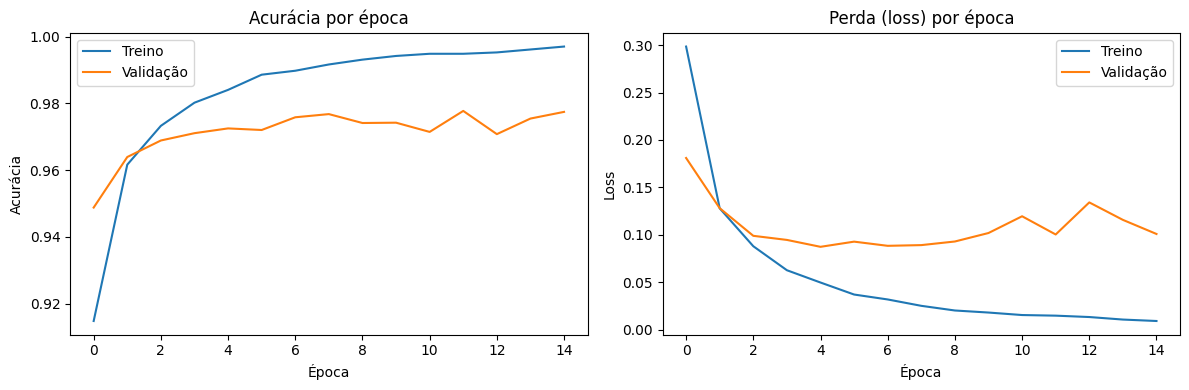

In [ ]:
#Visualizando as curvas de treino

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(historico_final.history['accuracy'], label='Treino')
plt.plot(historico_final.history['val_accuracy'], label='Validação')
plt.title('Acurácia por época')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(historico_final.history['loss'], label='Treino')
plt.plot(historico_final.history['val_loss'], label='Validação')
plt.title('Perda (loss) por época')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
#Guardando no painel geral

resultados_modelos['Rede Neural (MLP)'] = {
    'melhores_hiperparametros': melhor_config_rn,
    'acuracia_validacao': historico_final.history['val_accuracy'][-1],
    'tempo_treino_segundos': tempo_treino_rn
}

resultados_modelos

{'KNN': {'melhores_hiperparametros': {'n_neighbors': 5, 'weights': 'distance'},
  'acuracia_validacao': np.float64(0.9719047619047619),
  'tempo_treino_segundos': 0.049833059310913086},
 'Random Forest': {'melhores_hiperparametros': {'n_estimators': 100,
   'max_depth': None},
  'acuracia_validacao': 0.9689523809523809,
  'tempo_treino_segundos': 42.60179567337036},
 'Rede Neural (MLP)': {'melhores_hiperparametros': {'neuronios_camada1': 128,
   'neuronios_camada2': 64,
   'learning_rate': 0.001},
  'acuracia_validacao': 0.9774285554885864,
  'tempo_treino_segundos': 88.18938326835632}}

## Interpretação dos Resultados: Modelo de Rede Neural (Keras/TensorFlow)

Nesta etapa, testei diferentes combinações de neurônios e taxas de aprendizado (*learning rate*) para classificar os dígitos do MNIST e analisei o comportamento do treinamento ao longo de 15 épocas.

**O que aprendi com os testes:**
* Com uma rede menor (64 e 32 neurônios), o treino foi bem rápido (22.8s), mas ela bateu 96,54% de acurácia. Pareceu faltar "espaço de memória" para pegar os traços mais difíceis dos números.
* Aumentar para 128 e 64 neurônios com a taxa de 0.001 foi a combinação que mais deu certo: a validação chegou a 97,30%, mesmo demorando um pouco mais (41.1s).
* Quando mantive esses mesmos 128 e 64 neurônios, mas aumentei a taxa para 0.01, o resultado caiu para 96,19%. Pelo visto, os "passos" de ajuste ficaram grandes demais e a rede acabou tropeçando e passando direto do ponto ideal.

**Analisando o treino do melhor modelo ao longo das 15 épocas:**
Olhando as curvas dos gráficos, reparei em um comportamento bem típico que vemos na teoria:

* **No treino:** a linha azul foi quase perfeita, chegando a 99,70% de acurácia e com a perda (*loss*) despencando até quase zero (0,0093).
* **Na validação:** a linha laranja de acurácia parou de subir por volta da época 5 a 7 (ficando em torno de 97,5%). Além disso, no gráfico da direita, a perda de validação começou a subir e oscilar depois da época 5 (foi de 0,0875 para mais de 0,13).
* **Diagnóstico:** A rede sofreu *overfitting*. A partir da época 6 ou 7, ela basicamente parou de aprender coisas úteis sobre os números e começou a apenas "decorar" os exemplos do treino.

**O que fazer diferente na próxima:**
* Treinar as 15 épocas completas levou 88 segundos sem necessidade real. Daria para economizar tempo parando o treino ali pela época 6 ou 7 usando **Early Stopping**.
* Para diminuir essa tendência de decorar os dados, vale a pena testar camadas de **Dropout** antes de treinar de novo.


